In [1]:
from IPython.display import display

from tqdm import tqdm 
from datetime import datetime

import pandas as pd
pd.set_option('display.float_format', '{:.00f}'.format)

import numpy as np

import missingno as msno

In [2]:
platformID = 'TTK'

## import helper

In [3]:
import sys
from pathlib import Path

try:
    # Works in Python scripts
    helper_path = Path(__file__).resolve().parent.parent / "helper"
except NameError:
    # Works in Jupyter notebooks
    helper_path = Path().resolve().parent / "helper"

sys.path.insert(0, str(helper_path))

# Now import your modules
from config import gam_info

import test_functions 
import functions 

In [4]:
# country
pop_size_col = gam_info['population_column']
country_cols = ['PlaceID', pop_size_col]
country_codes = pd.read_excel(f"../../{gam_info['lookup_file']}", sheet_name='CountryID', 
                              keep_default_na=False)[country_cols]

# week 
week_tester = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                            sheet_name='GAM Period',)
week_tester['w/c'] = pd.to_datetime(week_tester['w/c'])

# social media accounts
socialmedia_accounts = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                                     sheet_name='Social Media Accounts new')

socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['Year'] == gam_info['file_timeinfo']]
socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['PlatformID'] == platformID]
socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['Status'] == 'active']

channel_ids = socialmedia_accounts['Channel ID'].unique().tolist()
formatted_channel_ids = ', '.join(f"'{channel_id}'" for channel_id in channel_ids)

# overlaps 
overlaps = pd.read_excel(f"../../{gam_info['lookup_file']}", sheet_name='overlap')

### RUN TESTS
test_functions.test_lookup_files(country_codes, country_cols, [f"{platformID}_4_0", f"{platformID}_4_1", f"{platformID}_4_2"], 
                                 test_step="lookup files - ensuring country codes is correct")

test_functions.test_lookup_files(week_tester, ['w/c'], [f"{platformID}_4_3", f"{platformID}_4_4", f"{platformID}_4_5"], 
                                 test_step = "lookup files - ensuring week tester is correct")

test_functions.test_lookup_files(socialmedia_accounts, ['Channel ID'], [f"{platformID}_4_6", f"{platformID}_4_7", f"{platformID}_4_8"], 
                                 test_step = "lookup files - ensuring social media accounts is correct")


✅ Test TTK_4_0 passed: lookup DataFrame is not empty.
...updating logbook...

✅ Test TTK_4_1 passed: No combinations occurs more than once a week.
...updating logbook...

✅ Test TTK_4_2 passed: No missing values in lookup.
...updating logbook...

✅ Test TTK_4_3 passed: lookup DataFrame is not empty.
...updating logbook...

✅ Test TTK_4_4 passed: No combinations occurs more than once a week.
...updating logbook...

✅ Test TTK_4_5 passed: No missing values in lookup.
...updating logbook...

✅ Test TTK_4_6 passed: lookup DataFrame is not empty.
...updating logbook...

✅ Test TTK_4_7 passed: No combinations occurs more than once a week.
...updating logbook...

✅ Test TTK_4_8 passed: No missing values in lookup.
...updating logbook...



## import data 

In [5]:
full_df = pd.read_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_uniqueViewer_country.csv")
print(full_df.shape)

full_df = full_df.merge(country_codes, on='PlaceID', 
                        how='left', indicator=True)
print(full_df._merge.value_counts())
full_df.drop(columns=['_merge'], inplace=True)
full_df.sample()

(378568, 5)
_merge
both          378568
left_only          0
right_only         0
Name: count, dtype: int64


,w/c,PlaceID,ServiceID,Channel ID,uv_by_country,Population2020
155388,2025-09-15,ROM,BNO,3d596e6a-d239-434e-bb79-93e5d291b216,11,14845869


# calculate 

In [6]:
path = f"../data/singlePlatform/{platformID}/"

## Business Units

### processing WSL ######################################################
{'Service IDs': ['AFA', 'FRE', 'AMH', 'ARA', 'AZE', 'BEN', 'POR', 'BUR', 'MAN', 'DAR', 'FAR', 'KRW', 'GUJ', 'HAU', 'HIN', 'IGB', 'INO', 'KOR', 'KYR', 'ELT', 'MAR', 'SPA', 'NEP', 'PAS', 'PER', 'PDG', 'POL', 'PUN', 'RUS', 'SER', 'SIN', 'SOM', 'SWA', 'TAM', 'TEL', 'THA', 'TIG', 'TUR', 'ECH', 'UKR', 'URD', 'UZB', 'VIE', 'YOR'], 'exclude_UK': False, 'sainsbury': {'TWI': True, 'YT-': True, 'FBE': True, 'TTK': True, 'INS': True}}
sainsbury is applied
saved weekly file for WSL as:
 ../data/singlePlatform/TTK/weekly//GAM2026_WEEKLY_TTK_WSLbyCountry.xlsx
### processing GNL_ ######################################################
{'Service IDs': ['BNI', 'BNO'], 'exclude_UK': True, 'sainsbury': {'TWI': True, 'YT-': True, 'FBE': True, 'TTK': True, 'INS': True}}
sainsbury is applied
saved weekly file for GNL_ as:
 ../data/singlePlatform/TTK/weekly//GAM2026_WEEKLY_TTK_GNL_byCountry.xlsx
### processing WOR #######################

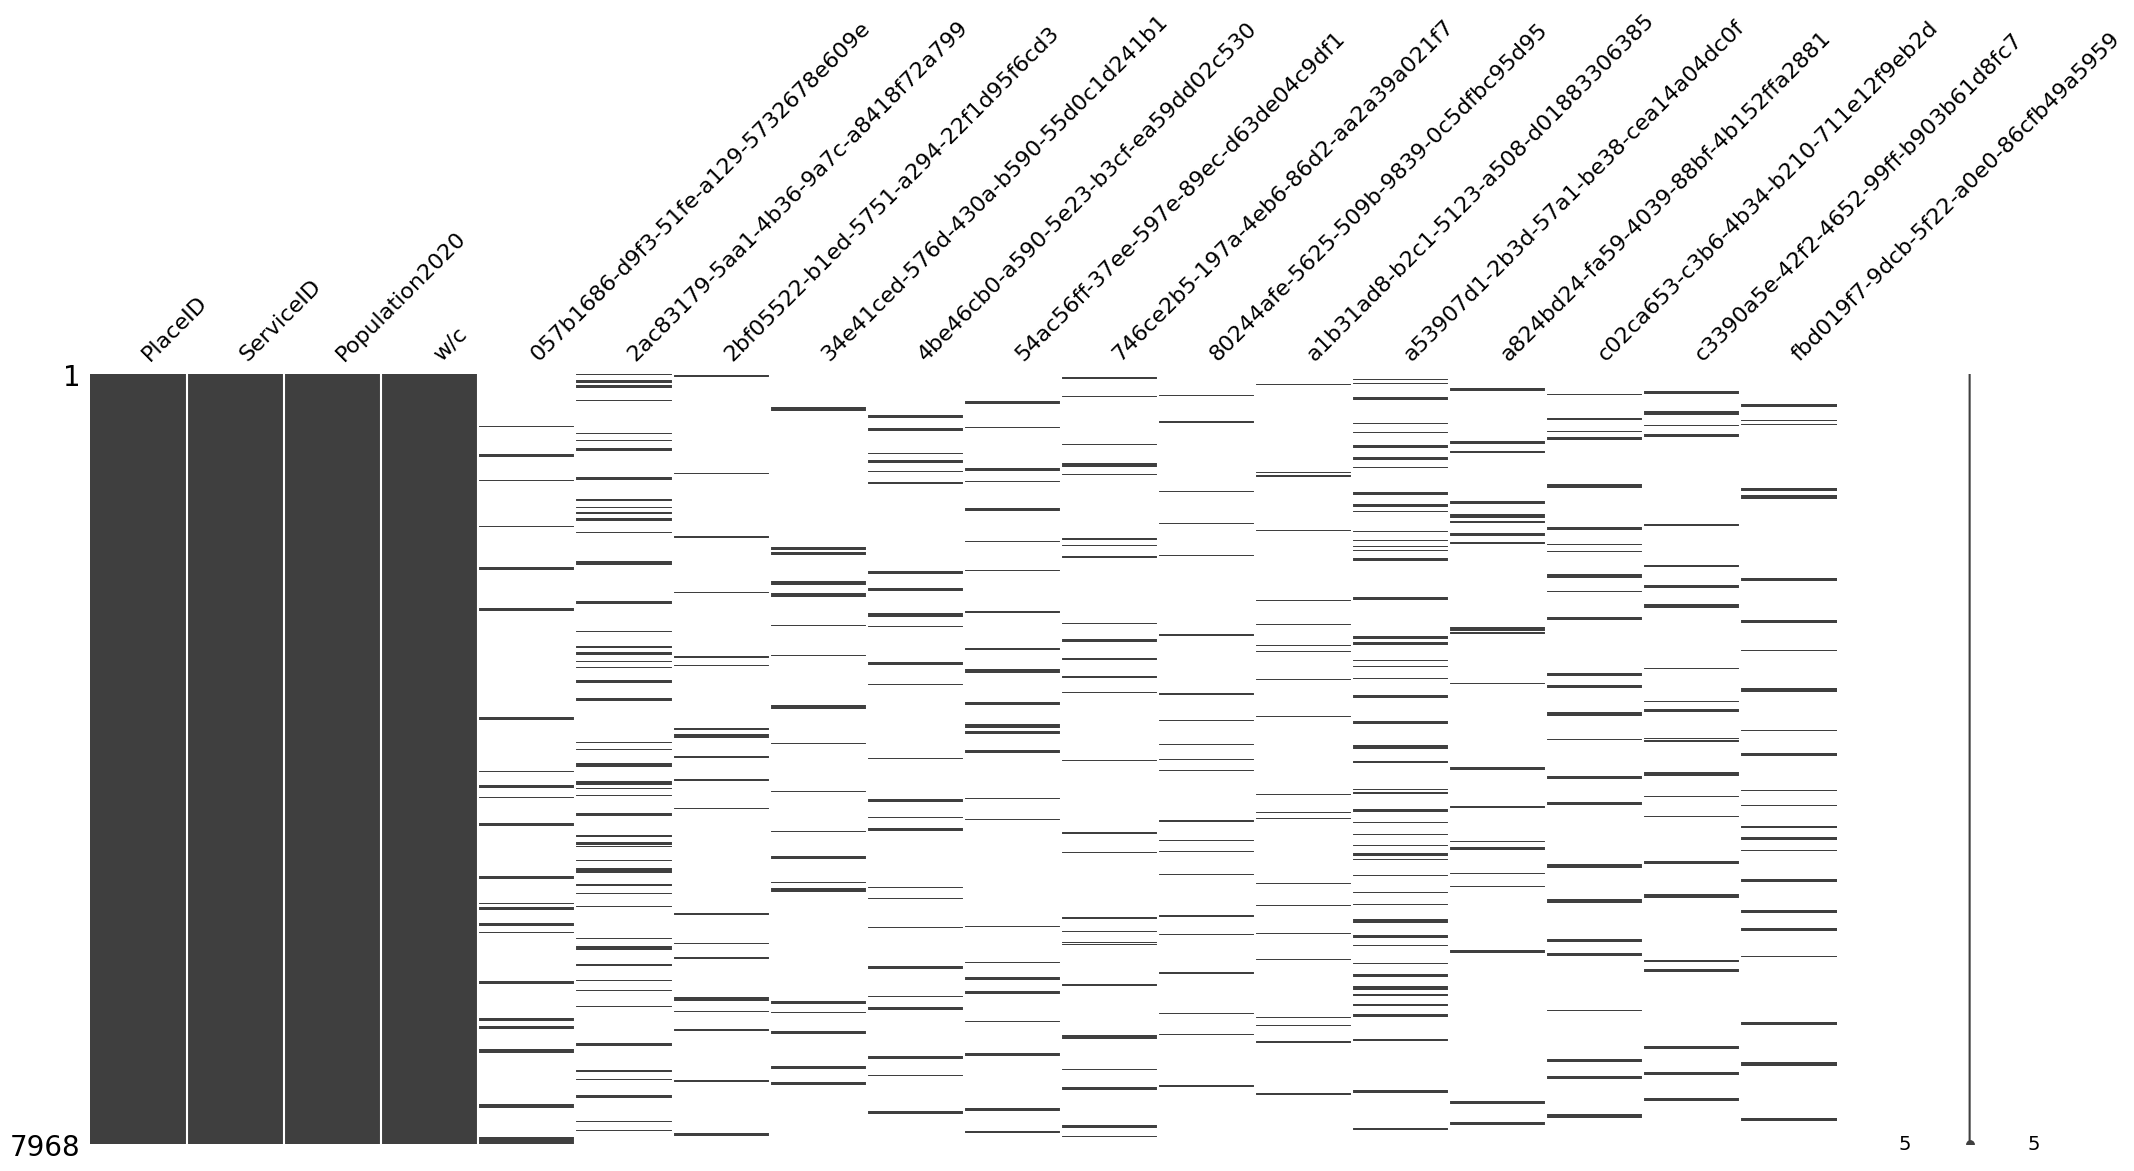

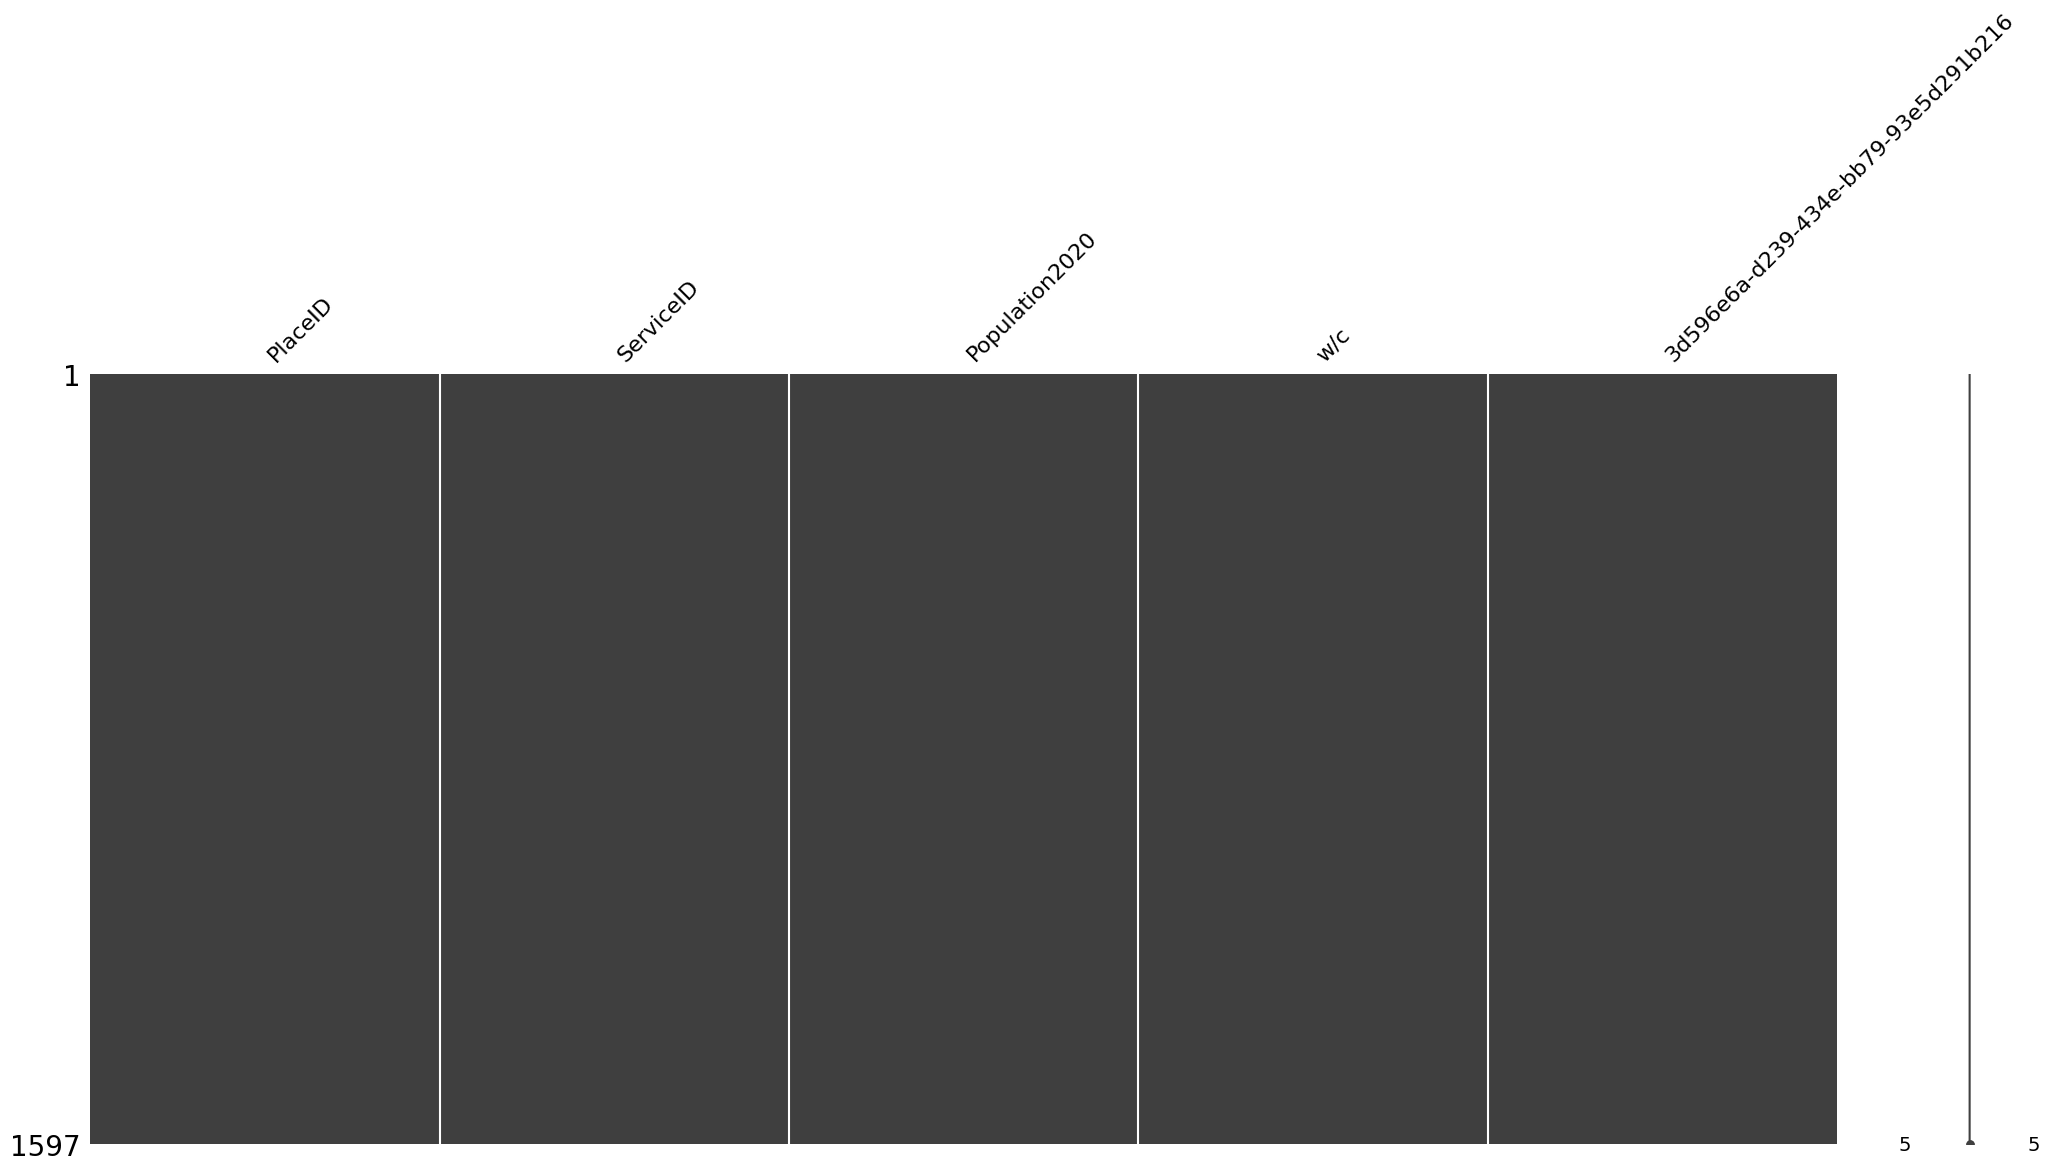

In [7]:

data = {}
'''temp_bus = ['GNL', 'WSL', 'GNL','Studios', 'WSE', 'MA-', 'FOA']
for bu in temp_bus:
'''#
for bu in gam_info['business_units'].keys():
    print(f"### processing {bu} ######################################################")
    data[bu] = {'weekly': pd.DataFrame(),
                'annual': pd.DataFrame()}
    bu_configs = gam_info['business_units'][bu]
    print(bu_configs)
    df = full_df[full_df['ServiceID'].isin(gam_info['business_units'][bu]['Service IDs'])]
    
    if df.empty:
        print(f"no data yet for {bu}")
        continue
        
    channel_ids = df['Channel ID'].unique().tolist()
    
    # will include / exclude the uk based on bu_configs
    df = functions.include_uk_decision(df, socialmedia_accounts)
    
    # for later testing or if sainsbury isn't used 
    summed_uv_by_country = df.groupby(['ServiceID', 'w/c', 'PlaceID', pop_size_col])\
                                .agg({'uv_by_country': 'sum'})\
                                .reset_index()
    
    if bu_configs['sainsbury'][platformID]:
        print('sainsbury is applied')
        # pivot 
        channel_uv_by_country = pd.crosstab(
                                        index = [ df['PlaceID'], 
                                                  df['ServiceID'], 
                                                  df[pop_size_col], 
                                                  df['w/c']],
                                        columns = df['Channel ID'],
                                        values =  df['uv_by_country'],
                                        aggfunc='sum'
                                    ).reset_index()
    
        # check for missing values
        # especially in the string columns no values should be missing
        msno.matrix(channel_uv_by_country)
        
        # fill missing values with 0 - this is good fi the matrix above showed that the string 
        # columns did not have any missings so the only gaps filled are numeric. 
        channel_uv_by_country = channel_uv_by_country.fillna(0)
        
        #calculate sainsbury
        channel_uv_by_country = functions.sainsbury_formula(channel_uv_by_country, pop_size_col, 
                                      channel_ids, 'uv_by_country')
        channel_uv_by_country = channel_uv_by_country.drop(columns=channel_ids)
        
        cols_left =  ['w/c', 'PlaceID', 'uv_by_country']
        cols_right = ['w/c', 'PlaceID', 'ServiceID', 'uv_by_country']
        #yt_deduped = channel_uv_by_country[cols_left].merge(summed_uv_by_country[cols_right], on=['w/c', 'PlaceID'], how='inner')
        yt_deduped = channel_uv_by_country.rename(columns={'uv_by_country': 'Reach'})
        
    else:
        print('sainsbury is skipped ')
        # instead of pivot we can use the summed df above that already contains the sum over 
        # YT Service Code so the channels are already summarised in Services
        yt_deduped = summed_uv_by_country.rename(columns={'uv_by_country': 'Reach'})
    
    # processing 
    weekly_df= functions.summary_excel(yt_deduped, bu, platformID, gam_info)
    
    # storing data
    data[bu]['weekly'] = weekly_df
    
    

## AXE

In [8]:

data['AXE'] = {'weekly': pd.DataFrame()}
temp = data['WSL']['weekly']
data['AXE']['weekly'] = functions.calculate_weekly_Services(temp, 'AXE', platformID, pop_size_col,
                                                               gam_info, 'sum') 

# TODO add explainer to make clear how a new service is created (BNI BNO breakout in GNL)
data['GNL'] = {'weekly': pd.DataFrame()}
temp = data['GNL_']['weekly']
data['GNL']['weekly'] = functions.calculate_weekly_Services(temp, 'GNL', platformID, pop_size_col,
                                                  gam_info) 

## AX2, ANW, ANY, TOT, ALL, ENG, EN2 ENW


In [9]:
path = f"../data/singlePlatform/{platformID}/"
stages = [
        # (grouped_service, service1, service2, overlap_type, overlap_service_id, use_v2, optional_service3)
        ('AX2', 'FOA', 'AXE', 'WSL/FOA', 'FOA', False, None),
        ('ANW', 'AX2', 'WSE', 'WSE/WSL', 'AXE', False, None),
        ('ANY', 'GNL', 'ANW', 'WSL/GNL', 'ANW', False, None),
        ('TOT', 'MA-', 'ANY', 'sainsbury', '-', False, None),
        ('ALL', 'TOT', 'WOR', 'sainsbury', '-', False, None),
        ('ENG', 'GNL', 'WSE', 'sainsbury', '-', False, None),
        ('EN2', 'GNL', 'WSE', 'other', '-', True, 'WOR'),
        ('ENW', 'WSE', 'FOA', 'sainsbury', '-', False, None)
    ]
data = functions.calculate_aggregated_services(data, stages, platformID, gam_info, path, overlaps, 
                                                country_codes, pop_size_col)


Only AXE available. Using it as AX2.
calculating annual by the new method
Only AX2 available. Using it as ANW.
calculating annual by the new method
overlap applied: 0.106934
calculating annual by the new method
Only ANY available. Using it as TOT.
calculating annual by the new method
Only TOT available. Using it as ALL.
calculating annual by the new method
Only GNL available. Using it as ENG.
calculating annual by the new method
calculating annual by the new method
No data to process for WSE and FOA. Skipping.


In [10]:
# test hierarchies


# Combine all 'weekly' DataFrames
cols = ['PlaceID', 'ServiceID', 'w/c', 'Reach', ]
combined_weekly = pd.concat(
    [v['weekly'] for v in data.values() if 'weekly' in v],
    ignore_index=True
)[cols]

print(combined_weekly.shape)
combined_weekly.sample()
combined_weekly['PlatformID'] = platformID
# SERVICE hierarchy issues
test_step = "calculated high-level services"
service_hierarchy_issues = test_functions.test_hierarchy_reach(f"{platformID}_4_9", 
                                                               'Service', 
                                                               gam_info, 
                                                               combined_weekly, 
                                                               ['w/c', 'PlaceID'],
                                                               metric_col='Reach',
                                                               test_step= test_step, 
                                                                round_metric=True)


(34675, 4)
...updating logbook...

✅ All tests passed.


In [11]:
combined_weekly.head()

,PlaceID,ServiceID,w/c,Reach,PlatformID
0,AFG,AZE,2025-07-28,5683,TTK
1,AFG,INO,2025-08-11,5,TTK
2,AFG,POR,2025-06-16,5,TTK
3,AFG,POR,2025-07-28,42,TTK
4,ALB,INO,2025-05-26,1,TTK


In [12]:
global_reach = combined_weekly.groupby(['ServiceID', 'w/c'])['Reach'].sum().reset_index()

In [13]:
global_reach[#(combined_weekly['ServiceID'] == ) & 
    (global_reach['w/c'] == '2025-10-27') ].sort_values('Reach', ascending=False) # should be AX2=mio

,ServiceID,w/c,Reach
30,ALL,2025-10-27,47341030
98,ANY,2025-10-27,47341030
656,TOT,2025-10-27,47341030
64,ANW,2025-10-27,34850460
184,AXE,2025-10-27,34850460
150,AX2,2025-10-27,34850460
554,SPA,2025-10-27,15095845
268,BNO,2025-10-27,13219942
370,ENG,2025-10-27,13219942
404,GNL,2025-10-27,13219942
